## Time Series Forecasting using Recurrent Neural Networks (RNN) in TensorFlow

Time series data such as stock prices are sequence that exhibits patterns such as trends and seasonality. Each data point in a time series is linked to a timestamp which shows the exact time when the data was observed or recorded. Many fields including finance, economics, weather forecasting and machine learning use this type of data. Due to these characteristics we can use Recurrent Neural Networks (RNN) for prediction as they work fine on sequential data.

To demonstrate the same we're going to use stock price data the most popular type of time series data.

### 1. Importing required libraries

We will import some libraries such as numpy, pandas, matplotlib, yfinance, scikit learn and tensorflow.


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN



### 2. Fetching Data from Yahoo Finance

We are fetching data from yahoo finance using its API yfinance.

* **values.reshape(-1, 1):** reshapes the data to be in a 2D array required for RNN input.
* **We extract the Close** price from the dataset which is commonly used for forecasting in stock prediction models.
* **values.reshape(-1, 1):** reshapes the data into a 2D array for use in the model.

In [34]:
ticker = 'AAPL'
data = yf.download(ticker, start='2010-01-01', end='2023-01-01')
values = data['Close'].values.reshape(-1, 1)

[*********************100%***********************]  1 of 1 completed


### 3. Normalizing the Data


In [43]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

In [36]:
data.head(3)

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2010-01-04,6.412385,6.427067,6.363545,6.395006,493729600
2010-01-05,6.423469,6.459724,6.389610,6.430061,601904800
2010-01-06,6.321296,6.448939,6.314704,6.423470,552160000


In [37]:
values[:5]

array([[6.41238499],
       [6.42346907],
       [6.32129622],
       [6.30960941],
       [6.35155678]])

### 4. Preparing the Data for Time Series


In [47]:
def create_dataset(dataset, time_step=60):
    X, y = [], []
    for i in range(len(dataset) - time_step - 1):
        X.append(dataset[i:(i + time_step), 0])
        y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(y)

X, y = create_dataset(scaled_data)
X = X.reshape(X.shape[0], X.shape[1], 1)

### 5. Splitting the Data into Training and Testing Sets


In [48]:
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

### 6. Building the RNN Model

The model which we are using here is a Recurrent Neural Network (RNN). It s used for sequential data modeling such as time series forecasting.

The model is built using SimpleRNN layers.
* units=50 defines the number of units (neurons) in each RNN layer.
* return_sequences=True in the first RNN layer ensures that the output is fed to the next RNN layer.
* Dense(units=1) is the output layer, predicting a single value i.e the next stock price.
* The model is compiled using the Adam optimizer and Mean Squared Error loss function.


In [49]:
model = Sequential()
model.add(SimpleRNN(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(SimpleRNN(units=50 , return_sequences=True))
model.add(Dense(units=1))
model.compile(optimizer='adam', loss='mean_squared_error')

c:\Users\PANDIT JI\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### 7. Training the Model


In [55]:
model.fit(X_train, y_train, epochs=20, batch_size=32)

prediction = model.predict(X_test)
prediction = prediction.reshape(-1, 1)
prediction = scaler.inverse_transform(prediction)

Epoch 1/20
 1/81 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 0.0053

81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0089
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0090
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0092
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0094
Epoch 5/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0092
Epoch 6/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - loss: 0.0089
Epoch 7/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - loss: 0.0093
Epoch 8/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - loss: 0.0090
Epoch 9/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.0088
Epoch 10/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0091
Epoch 11/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0092
Epoch 12/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0091
Epoch 13/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0087
Epoch 14/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0089
Epoch 15/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0087
Epoch 16/20
81

### 8. Evaluating the model


In [52]:
y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1, 1))

mse = mean_squared_error(y_test_unscaled, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_unscaled, predictions)

print(f"Unscaled Mean Squared Error (MSE): {mse}")
print(f"Unscaled Root Mean Squared Error (RMSE): {rmse}")
print(f"Unscaled Mean Absolute Error (MAE): {mae}")

Unscaled Mean Squared Error (MSE): 12782.236846695836
Unscaled Root Mean Squared Error (RMSE): 113.0585549469647
Unscaled Mean Absolute Error (MAE): 111.10240781436997


### 9. Visualizing the Results

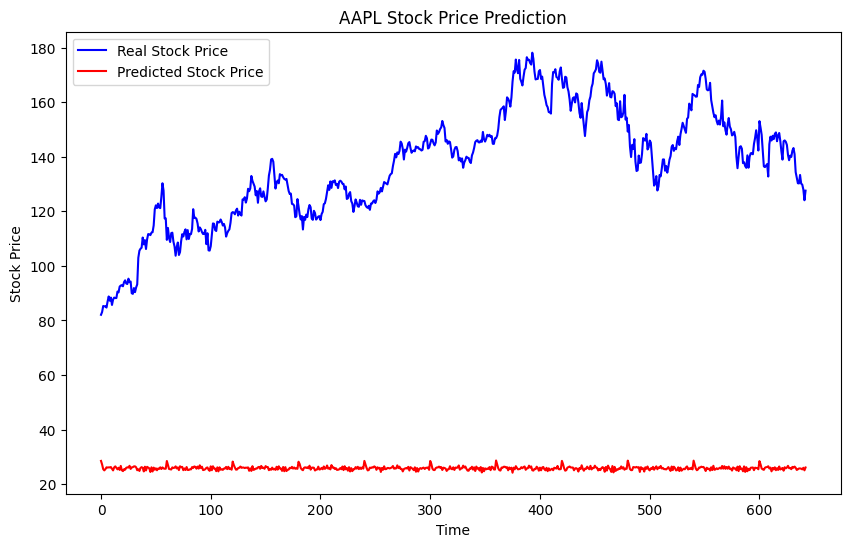

In [54]:
plt.figure(figsize=(10,6))
plt.plot(scaler.inverse_transform(y_test.reshape(-1, 1)), color='blue', label='Real Stock Price')
plt.plot(predictions, color='red', label='Predicted Stock Price')
plt.title(f'{ticker} Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

The graph shows the performance of a RNN model in predicting Apple (AAPL) stock prices. The blue line represents the actual stock prices from the test data while the red line shows the predicted values. The RNN model successfully captures the underlying trends in the stock price with the predicted values closely following the actual prices. Although minor deviations are observed the overall prediction shows that model effectively learned the temporal patterns in stock data.

